In [ ]:
def initialize_data(tissue_type):
    #corrected
    import pandas as pd
    import numpy as np

# Paths to input files
    blood_file = '/shares/sinha/epallapotu/blood_expression_project/gene_tpm_v10_whole_blood.gct.gz'
    protein_file = '/shares/sinha/epallapotu/blood_expression_project/gene_with_protein_product.txt'
    delta_file = '/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv'

    # Load data
    protein_data = pd.read_csv(protein_file, sep='\t')
    blood_data = pd.read_csv(blood_file, sep='\t', compression='gzip', skiprows=2)

    # Keep only genes present in both protein list and blood data
    common_genes = np.intersect1d(protein_data["symbol"], blood_data["Description"])
    blood_protein_data = blood_data[blood_data['Description'].isin(common_genes)]

    # Truncate column names (patient IDs) to first 9 characters
    blood_protein_data.columns = [col[:9] if len(col) >= 9 else col for col in blood_protein_data.columns]
    blood_protein_data = blood_protein_data.rename(columns={'Descripti': 'Description'})  # Fix truncation from previous line

    # Resolve duplicate patient columns by averaging
    blood_protein_data = (
        blood_protein_data
        .set_index(['Name', 'Description'])
        .groupby(level=0, axis=1)
        .mean()
        .reset_index()
    )

    # Read and process delta data
    delta_data = pd.read_csv(delta_file, sep='\t')
    delta_data["Patients"] = delta_data["sample_id"].str[:9]
    delta_data = delta_data.drop(columns='sample_id')
    tissue_data = delta_data[delta_data["tissue"] == (tissue_type)]

    return blood_protein_data, tissue_data, protein_data, delta_data

In [ ]:
import numpy as np
import random
from scipy.stats import pearsonr

def shuffle_and_compute(args):
    count, blood_protein_data_filtered, original_data2 = args
    shuffled_data2 = original_data2.copy()
    random.shuffle(shuffled_data2)

    random_pearson_list = []
    for _, row in blood_protein_data_filtered.iterrows():
        data1 = row.values
        mask = np.isfinite(data1) & np.isfinite(shuffled_data2)
        data1 = data1[mask]
        data2 = shuffled_data2[mask]
        if len(data1) < 2 or np.std(data1) == 0 or np.std(data2) == 0:
            continue
        try:
            corr, _ = pearsonr(data1, data2)
            random_pearson_list.append(corr)
        except Exception:
            continue

    if random_pearson_list:
        return max(random_pearson_list), min(random_pearson_list)
    else:
        return None

In [ ]:

from scipy.stats import pearsonr
import numpy as np

def compute_pearson(args):
    index, row, data2, name, description = args

    # Remove NaNs from both vectors
    valid_mask = (~np.isnan(row)) & (~np.isnan(data2))
    x = row[valid_mask]
    y = data2[valid_mask]

    try:
        if len(x) < 2:
            return None
        corr, p = pearsonr(x, y)
        return {
            'Pearson': corr,
            'P_value': p,
            'Name': name,
            'Description': description,
        }
    except Exception:
        return None

In [ ]:
def correlation_overtheline_patients_get_data(tissue_type):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import math
    import statistics
    import random
    from concurrent.futures import ProcessPoolExecutor
    from tqdm import tqdm
    from scipy.stats import pearsonr

    # Load data
    blood_protein_data, tissue_data, protein_data, delta_data = initialize_data(tissue_type)

    # Reshape delta values to per-patient format
    new_df = tissue_data[['Patients', 'delta']]
    delta_data_patient = pd.DataFrame([new_df['delta'].values], columns=new_df['Patients'])
    delta_data_patient.index = ['delta']

    unique_cols_delta = delta_data_patient.columns.unique().to_list()
    result_list = []

    for col in unique_cols_delta:
        duplicate_cols_delta = delta_data_patient.loc[:, delta_data_patient.columns == col]
        if duplicate_cols_delta.shape[1] > 1:
            averaged = duplicate_cols_delta.mean(axis=1)
        else:
            averaged = duplicate_cols_delta.iloc[:, 0]
        result_list.append(pd.DataFrame({col: averaged}))

    delta_data_patient = pd.concat(result_list, axis=1)

    # Align on common patients
    common_cols = blood_protein_data.columns.intersection(delta_data_patient.columns)
    blood_protein_data_filtered = blood_protein_data[common_cols]
    delta_data_patient = delta_data_patient[common_cols]
    data2 = delta_data_patient.to_numpy().flatten()

    # Prepare input for parallel Pearson calculation
    tasks = []
    for counter_gene, (index, row) in enumerate(blood_protein_data_filtered.iterrows()):
        name = blood_protein_data["Name"].iloc[counter_gene]
        description = blood_protein_data["Description"].iloc[counter_gene]
        tasks.append((index, row.values, data2, name, description))

    results_list = []
    with ProcessPoolExecutor() as executor:
        for result in tqdm(executor.map(compute_pearson, tasks), total=len(tasks)):
            if result:
                results_list.append(result)

    df_final_results = pd.DataFrame(results_list)

    # Parallelized shuffle section: build null distribution
    max_pearson_values = []
    min_pearson_values = []
    original_data2 = data2.copy()

    args_list = [(count, blood_protein_data_filtered, original_data2) for count in range(100)]

    with ProcessPoolExecutor() as executor:
        results = list(tqdm(executor.map(shuffle_and_compute, args_list), total=100))
    for res in results:
        if res:
            max_val, min_val = res
            max_pearson_values.append(max_val)
            min_pearson_values.append(min_val)

    avg_max_shuffle = statistics.mean(max_pearson_values) if max_pearson_values else None
    avg_min_shuffle = statistics.mean(min_pearson_values) if min_pearson_values else None

    from sklearn.linear_model import LinearRegression
    # # Plot results
    # fig, ax = plt.subplots(figsize=(8, 6))
    # log_p_value_list = [-math.log(p) if p > 0 else 0 for p in df_final_results['P_value']]

    #to find the number of points that is above the line
    # Count points to the right of the red line (Pearson > shuffled max)
    points_right_of_line = df_final_results['Pearson'] > avg_max_shuffle
    count_above_line = points_right_of_line.sum()
    percent_above_line = (count_above_line / len(df_final_results)) * 100
    # ax.text(0.75, 5, f"{percent_above_line:.2f}% genes right of shuffled max",
    #         fontsize=14, color='pink', ha='center', va='bottom')

    # Count points to the left of the red line
    points_left_of_line = df_final_results['Pearson'] < avg_min_shuffle
    count_below_line = points_left_of_line.sum()
    percent_below_line = (count_below_line / len(df_final_results)) * 100
    # ax.text(-0.75, 5, f"{percent_below_line:.2f}% genes left of shuffled max",
    #         fontsize=14, color='green', ha='center', va='bottom')

    total_percent_out_line= percent_below_line+percent_above_line
    # ax.text(0.75, 8, f"{total_percent_out_line:.2f}% genes percentage total over the line.",
    #         fontsize=14, color='orange', ha='center', va='bottom')

    number_of_genes_overline= (total_percent_out_line*(len(df_final_results['Pearson'])))/100
    # ax.text(-0.75, 8, f"{number_of_genes_overline:.2f} genes total over the line.",
    #         fontsize=14, color='brown', ha='center', va='bottom')

    #number of total patients per sample
    number_of_patients= len(common_cols)
    #ax.text(-0.75, 10, f"{number_of_patients:.2f} is the number of pateints in the data set",
          #fontsize=14, color='black', ha='center', va='bottom')
    #number_of_genes_in_dataset= len(df_final_results['Pearson'])
    # ax.text(0.75, 10, f"{number_of_genes_in_dataset:.2f} is the total genes being used in the data set.",
    #             fontsize=14, color='grey', ha='center', va='bottom')

    # if avg_max_shuffle is not None:
    #     ax.axvline(x=avg_max_shuffle, color='red', linestyle='--', linewidth=2,
    #                label=f"Avg max if shuffled: {avg_max_shuffle:.3f}")
    # else:
    #     print("error computing avg_max_shuffle")
    # if avg_min_shuffle is not None:
    #     ax.axvline(x=avg_min_shuffle, color='blue', linestyle='--', linewidth=2,
    #                label=f"Avg min if shuffled: {avg_min_shuffle:.3f}")
    # else:
    #     print("error computing avg_min_shuffle")

    # Report top features

    return number_of_patients,  total_percent_out_line


In [ ]:
def collect_correlation_overtheline_pateints_results():
    import pandas as pd
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()
    print(f"These are the unique tissues found:\n{unique_tissues}\n")
    # List of tissues to analyze
    tissue_list = unique_tissues
    patient_number_tissue=[]
    overline_percents_tissue=[]
    tissue_labels = []
    for tissue in tissue_list:
        if tissue not in unique_tissues:
            print(f"Tissue '{tissue}' not found in dataset. Skipping.")
            continue
        else:
            pass
        try:
            result = number_of_patients, total_percent_out_line = correlation_overtheline_patients_get_data(tissue)
            if result is not None:
                patient_number_tissue.append(number_of_patients)
                overline_percents_tissue.append(total_percent_out_line)
                tissue_labels.append(tissue)
            else:
                print(f" No figure returned for tissue '{tissue}'.")
        except Exception as e:
            print(f"Error processing tissue '{tissue}': {e}")

    return result, patient_number_tissue, overline_percents_tissue,  tissue_labels

In [ ]:
def activate_correlation_overtheline_patients():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    # Load delta data once


    from sklearn.linear_model import LinearRegression
    import numpy as np
    import matplotlib.pyplot as plt

    # Ensure these lists are defined and contain multiple values:
    # patient_number_tissue = [...]
    # overline_percents_tissue = [...]

    # Convert to NumPy arrays
    X = np.array(patient_number_tissue).reshape(-1, 1)
    y = np.array(overline_percents_tissue)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)

    color_palette = sns.color_palette("hsv", len(set(tissue_labels)))  # or "tab20", etc.
    tissue_to_color = {t: color_palette[i] for i, t in enumerate(sorted(set(tissue_labels)))}
    colors = [tissue_to_color[t] for t in tissue_labels]

        # Create plot
    fig, ax = plt.subplots(figsize=(10, 7))

    # Print coordinates
    for xi, yi, label in zip(X.flatten(), y, tissue_labels):
        print(f"Tissue: {label} -> (Patients: {xi}, Overline %: {yi:.2f})")

    # Scatter plot with tissue-based colors
    scatter = ax.scatter(X, y, c=colors, s=60, edgecolors='k')

    # Optionally label each point directly
    for xi, yi, label in zip(X.flatten(), y, tissue_labels):
        ax.text(xi, yi, label, fontsize=8, alpha=0.7)

    # Plot regression line
    X_fit = np.sort(X, axis=0)
    y_pred = model.predict(X_fit)
    ax.plot(X_fit, y_pred, color='red', linestyle='--', label='Regression Line')

    # Regression equation
    slope = model.coef_[0]
    intercept = model.intercept_

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.text(
        x=(x_min + x_max) / 2,
        y=y_min + 0.05 * (y_max - y_min),
        s=f'y = {slope:.2f}x + {intercept:.2f}',
        fontsize=12,
        color='green',
        ha='center'
    )

    # Axis labels and title
    ax.set_xlabel("Number of Patients")
    ax.set_ylabel("Genes over the margin line (%)")
    ax.set_title("Correlation between Patients and Genes over the Margin Line")

    # Legend for tissue colors
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=t,
                   markerfacecolor=tissue_to_color[t], markersize=8, markeredgecolor='k')
        for t in sorted(set(tissue_labels))
    ]
    ax.legend(handles=handles, title="Tissue Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.grid(True)
    plt.tight_layout()
    plt.show()


These are the unique tissues found:
['Adipose - Subcutaneous' 'Adrenal Gland' 'Artery - Aorta'
 'Artery - Coronary' 'Artery - Tibial' 'Brain - Cerebellum'
 'Brain - Cortex' 'Breast - Mammary Tissue' 'Colon - Sigmoid'
 'Colon - Transverse' 'Esophagus - Gastroesophageal Junction'
 'Esophagus - Mucosa' 'Esophagus - Muscularis' 'Heart - Atrial Appendage'
 'Heart - Left Ventricle' 'Kidney - Cortex' 'Liver' 'Lung'
 'Muscle - Skeletal' 'Nerve - Tibial' 'Ovary' 'Pancreas' 'Pituitary'
 'Prostate' 'Small Intestine - Terminal Ileum' 'Spleen' 'Stomach' 'Testis'
 'Thyroid' 'Uterus' 'Vagina']


--- Running analysis for tissue: Adipose - Subcutaneous ---


/tmp/ipykernel_4061560/104727419.py:12: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_data = pd.read_csv(protein_file, sep='\t')
/tmp/ipykernel_4061560/104727419.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1)
  6%|▋         | 1201/18917 [00:00<00:05, 3292.61it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 10%|█         | 1920/18917 [00:00<00:04, 3461.37it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 12%|█▏        | 2288/18


--- Running analysis for tissue: Adrenal Gland ---


/tmp/ipykernel_4061560/104727419.py:12: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_data = pd.read_csv(protein_file, sep='\t')
/tmp/ipykernel_4061560/104727419.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1)
  6%|▋         | 1190/18917 [00:00<00:05, 3131.05it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 11%|█▏        | 2163/18917 [00:00<00:05, 3005.04it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 15%|█▍        | 2820/18


--- Running analysis for tissue: Artery - Aorta ---


...

/tmp/ipykernel_4061560/104727419.py:12: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_data = pd.read_csv(protein_file, sep='\t')
/tmp/ipykernel_4061560/104727419.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1)
  5%|▍         | 931/18917 [00:00<00:05, 3285.41it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 10%|▉         | 1879/18917 [00:00<00:04, 4213.98it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 12%|█▏        | 2343/189


--- Running analysis for tissue: Uterus ---


/tmp/ipykernel_4061560/104727419.py:12: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_data = pd.read_csv(protein_file, sep='\t')
/tmp/ipykernel_4061560/104727419.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1)
  4%|▍         | 713/18917 [00:00<00:04, 3676.71it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
  9%|▉         | 1757/18917 [00:00<00:03, 4449.26it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 12%|█▏        | 2272/189


--- Running analysis for tissue: Vagina ---


/tmp/ipykernel_4061560/104727419.py:12: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_data = pd.read_csv(protein_file, sep='\t')
/tmp/ipykernel_4061560/104727419.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(level=0, axis=1)
  5%|▌         | 951/18917 [00:00<00:05, 3373.57it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
  8%|▊         | 1578/18917 [00:00<00:03, 4417.55it/s]/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
/tmp/ipykernel_4061560/2240724213.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = pearsonr(x, y)
 11%|█         | 2033/189

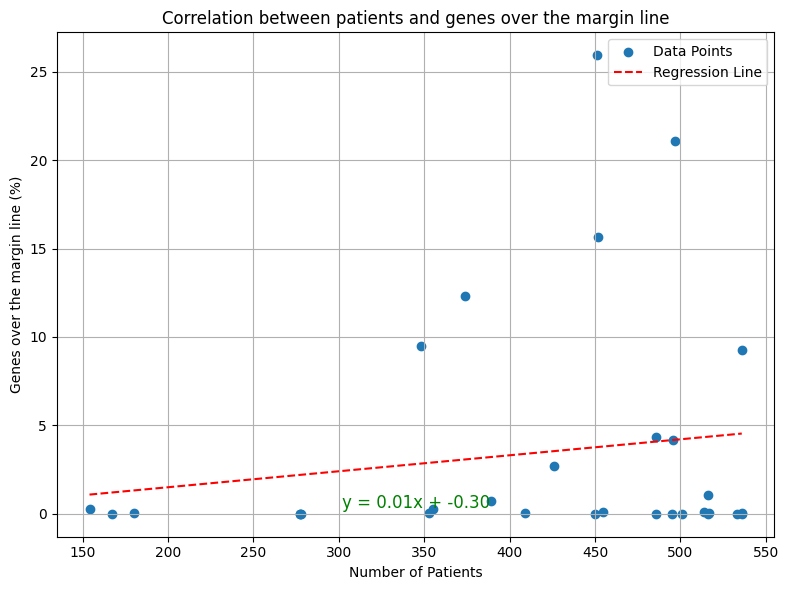

In [ ]:
activate_correlation_overtheline_patients()

In [ ]:
def data_store_correlation_overtheline_patients():
    import pandas as pd
    import matplotlib.pyplot as plt

    # Load delta data once
    delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
    unique_tissues = delta_data["tissue"].unique()
    print(f"These are the unique tissues found:\n{unique_tissues}\n")

    # List of tissues to analyze
    tissue_list = unique_tissues
    patient_number_tissue=[]
    overline_percents_tissue=[]
    for tissue in tissue_list:
        if tissue not in unique_tissues:
            print(f"Tissue '{tissue}' not found in dataset. Skipping.")
            continue

        print(f"\n--- Running analysis for tissue: {tissue} ---")
        try:
            result = number_of_patients, total_percent_out_line = correlation_overtheline_patients_get_data(tissue)
            if result is not None:
                patient_number_tissue.append(number_of_patients)
                overline_percents_tissue.append(total_percent_out_line)
            else:
                print(f" No figure returned for tissue '{tissue}'.")
        except Exception as e:
            print(f"Error processing tissue '{tissue}': {e}")